# Gözetimsiz Öğrenme ile Dolandırıcılık Tespiti
## Anomali Tespiti: **Isolation Forest** Çalışması

> **Belge türü:** Teknik analiz raporu & yeniden üretilebilir çalışma defteri
> **Alan:** Veri Bilimi / Gözetimsiz Makine Öğrenmesi — Anomali Tespiti
> **Yöntem:** Isolation Forest (`sklearn.ensemble.IsolationForest`)
> **Veri:** `creditcard.csv` — Kaggle Credit Card Fraud Detection (284.807 işlem)

---

### Yönetici Özeti

Bu çalışma, kredi kartı işlemlerinde **dolandırıcılığı (anomaliyi)** etiket kullanmadan tespit etmeyi hedefler. Veri **aşırı dengesizdir**: 284.807 işlemin yalnızca **492'si (%0,17)** dolandırıcılıktır. Bu rejimde klasik sınıflandırma ve doğruluk (accuracy) metrikleri yanıltıcıdır; bunun yerine **anomali tespiti** ve dengesizliğe duyarlı metrikler gerekir.

**Isolation Forest**, anomalileri "yoğunluk" üzerinden değil, **izole edilme kolaylığı** üzerinden bulur: rastgele bölmelerle bir noktayı ayırmak ne kadar az adım gerektiriyorsa, o nokta o kadar anormaldir. Bu, yüksek boyutlu veride mesafe/yoğunluk temelli yöntemlere (LOF, DBSCAN) kıyasla büyük bir avantajdır.

| Kriter | Isolation Forest |
|---|---|
| Çalışma ilkesi | Rastgele izolasyon ağaçları + yol uzunluğu |
| Etiket gereksinimi | ❌ Yok (gözetimsiz) |
| Yüksek boyut | ✅ Dayanıklı (mesafe kullanmaz) |
| Ölçekleme | Gerekmez (ağaç-temelli, eşik bölmeleri) |
| Hız / ölçeklenebilirlik | ✅ Yüksek (~doğrusal) |
| Çıktı | Her işleme bir **anomali skoru** |

## 1. Ortam ve Kütüphaneler

In [1]:
import warnings
warnings.filterwarnings("ignore")
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest, HistGradientBoostingClassifier
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve,
)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"
RANDOM_STATE = 42

import sklearn
print("numpy        :", np.__version__)
print("pandas       :", pd.__version__)
print("scikit-learn :", sklearn.__version__)
print("\nIsolationForest hazir.")

numpy        : 2.4.4
pandas       : 3.0.2
scikit-learn : 1.8.0

IsolationForest hazir.


## 2. Veri Yükleme ve Veri Sözlüğü

**Kaynak:** Kaggle — *Credit Card Fraud Detection* (`mlg-ulb`)
<https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud>

Veri, 2013'te Avrupa'da iki günlük kart işlemlerini içerir. Gizlilik nedeniyle özelliklerin çoğu **PCA ile anonimleştirilmiştir**.

| Sütun | Açıklama |
|---|---|
| `Time` | İlk işlemden bu yana geçen saniye |
| `V1`–`V28` | **PCA bileşenleri** (anonimleştirilmiş; zaten ~standardize) |
| `Amount` | İşlem tutarı |
| `Class` | **Hedef:** 0 = normal, 1 = dolandırıcılık (yalnız doğrulama için) |


In [2]:
DATA_PATH = "creditcard.csv" 
t0 = time.time()
df = pd.read_csv(DATA_PATH)
print(f"Yuklendi: {df.shape[0]:,} islem x {df.shape[1]} sutun  ({time.time()-t0:.1f}s)")
df.head()

Yuklendi: 284,807 islem x 31 sutun  (2.4s)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [4]:
# V1-V28 zaten PCA (standardize); Time/Amount/Class'a odaklaniyoruz
df[["Time", "Amount", "Class"]].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,94813.86,47488.15,0.0,54201.5,84692.0,139320.50,172792.00
Amount,284807.0,88.35,250.12,0.0,5.6,22.0,77.16,25691.16
Class,284807.0,0.00,0.04,0.0,0.0,0.0,0.00,1.00


## 3. Keşifsel Veri Analizi (EDA)

### 3.1 Sınıf Dengesizliği — Problemin Kalbi


In [5]:
print("Eksik deger toplam:", int(df.isna().sum().sum()))
print("Yinelenen satir   :", int(df.duplicated().sum()))
vc = df["Class"].value_counts()
print("\nSinif dagilimi:")
print(vc)
print(f"\nDolandiricilik orani: %{100*df['Class'].mean():.4f}  "
      f"(1 dolandirici : {int(vc[0]/vc[1])} normal)")

Eksik deger toplam: 0
Yinelenen satir   : 1081

Sinif dagilimi:
Class
0    284315
1       492
Name: count, dtype: int64

Dolandiricilik orani: %0.1727  (1 dolandirici : 577 normal)


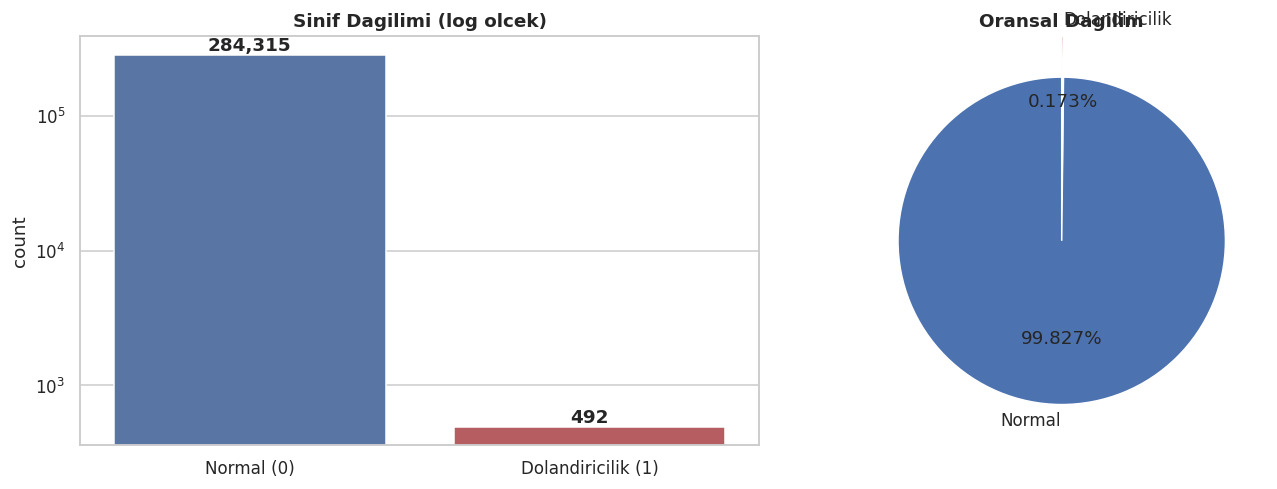

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
sns.countplot(data=df, x="Class", ax=axes[0], palette=["#4C72B0", "#C44E52"])
axes[0].set_yscale("log")
axes[0].set_title("Sinif Dagilimi (log olcek)")
axes[0].set_xticklabels(["Normal (0)", "Dolandiricilik (1)"])
axes[0].set_xlabel("")
for c, v in zip([0, 1], vc.values):
    axes[0].text(c, v, f"{v:,}", ha="center", va="bottom", fontweight="bold")

axes[1].pie(vc.values, labels=["Normal", "Dolandiricilik"],
            autopct="%.3f%%", colors=["#4C72B0", "#C44E52"],
            startangle=90, explode=[0, 0.25])
axes[1].set_title("Oransal Dagilim")
fig.tight_layout()
plt.show()

Dolandırıcılık binde 1,7. Bu dengesizlik, neden **accuracy'nin işe yaramadığını** açıkça gösterir: her şeye "normal" diyen model %99,83 doğruluk alır ama tek bir dolandırıcılığı yakalamaz.

### 3.2 Tutar (Amount) ve Zaman (Time) Dağılımları

Ortalama tutar -> Normal: $88.29 | Dolandiricilik: $122.21


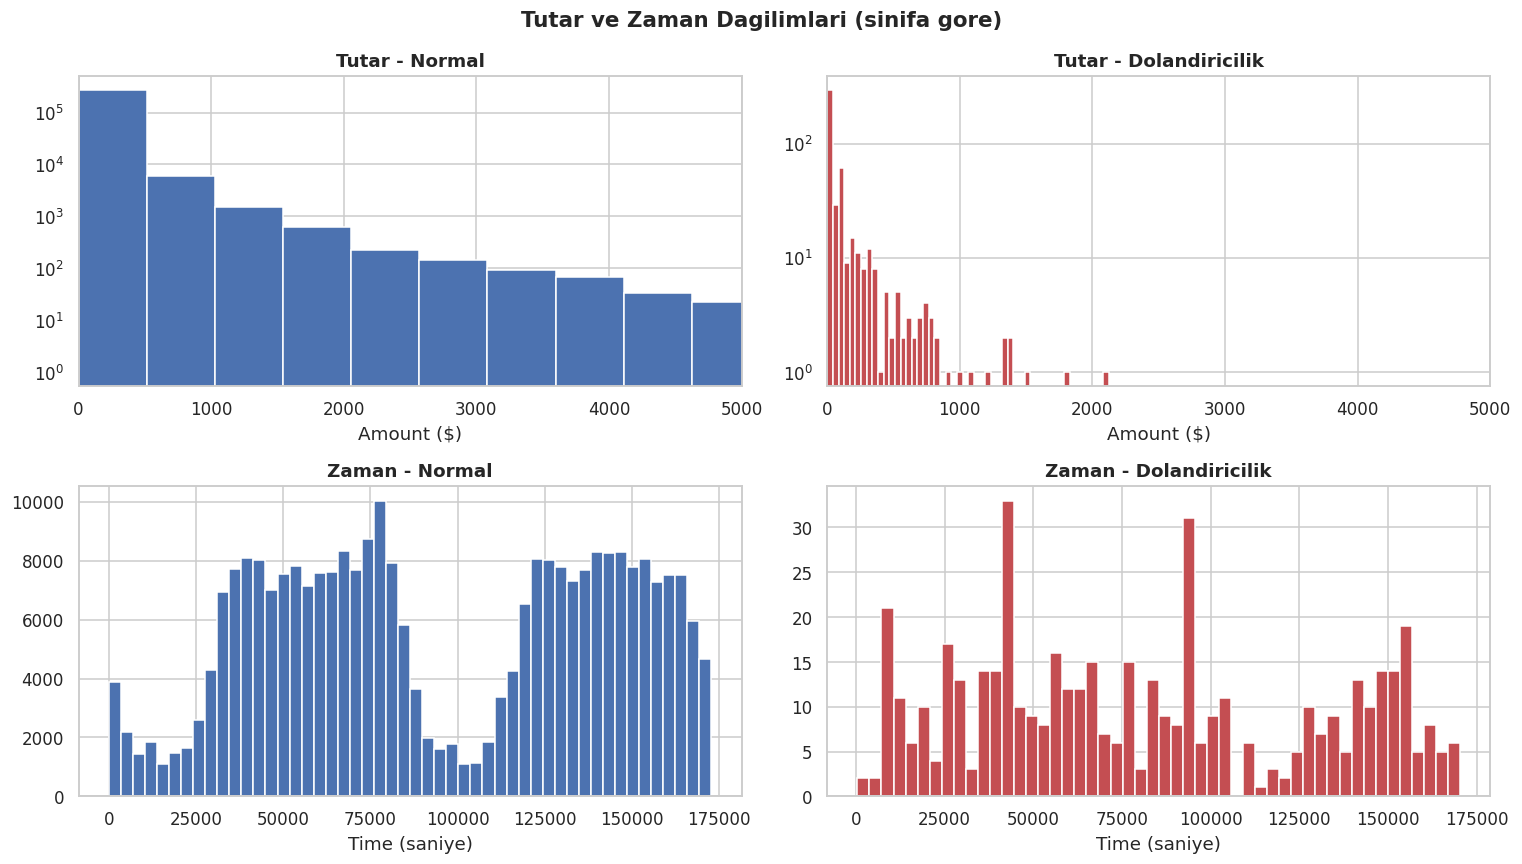

In [7]:
fraud = df[df["Class"] == 1]
normal = df[df["Class"] == 0]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes[0, 0].hist(normal["Amount"], bins=50, color="#4C72B0")
axes[0, 0].set_title("Tutar - Normal"); axes[0, 0].set_yscale("log")
axes[0, 1].hist(fraud["Amount"], bins=50, color="#C44E52")
axes[0, 1].set_title("Tutar - Dolandiricilik"); axes[0, 1].set_yscale("log")
for ax in axes[0]:
    ax.set_xlabel("Amount ($)"); ax.set_xlim(0, 5000)

axes[1, 0].hist(normal["Time"], bins=50, color="#4C72B0")
axes[1, 0].set_title("Zaman - Normal")
axes[1, 1].hist(fraud["Time"], bins=50, color="#C44E52")
axes[1, 1].set_title("Zaman - Dolandiricilik")
for ax in axes[1]:
    ax.set_xlabel("Time (saniye)")
fig.suptitle("Tutar ve Zaman Dagilimlari (sinifa gore)", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()
print(f"Ortalama tutar -> Normal: ${normal['Amount'].mean():.2f} | "
      f"Dolandiricilik: ${fraud['Amount'].mean():.2f}")

Dolandırıcılık tutarları görece **küçük ve dar bir aralıkta** yoğunlaşır; zamanda ise normal işlemler gün/gece ritmi gösterirken dolandırıcılık daha düzgün dağılır. Tek başına Amount/Time ayırt edici değildir — asıl sinyal PCA bileşenlerindedir.

### 3.3 En Ayırt Edici Özellikler

En ayirt edici 4 ozellik: ['V17', 'V14', 'V12', 'V10']


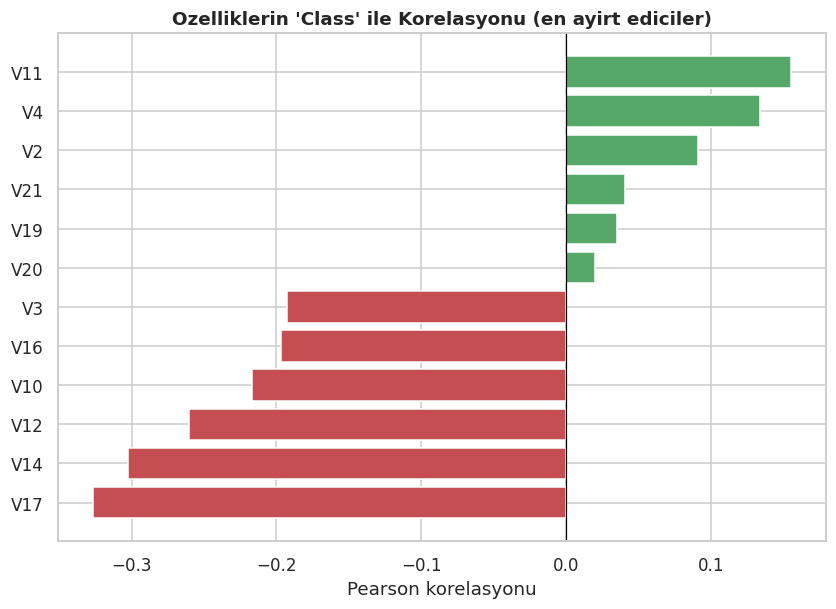

In [8]:
corr_class = df.corr()["Class"].drop("Class").sort_values()
top_neg = corr_class.head(6)
top_pos = corr_class.tail(6)
order_feats = pd.concat([top_neg, top_pos])

fig, ax = plt.subplots(figsize=(9, 6))
colors = ["#C44E52" if v < 0 else "#55A868" for v in order_feats.values]
ax.barh(order_feats.index, order_feats.values, color=colors)
ax.axvline(0, color="black", lw=0.8)
ax.set_title("Ozelliklerin 'Class' ile Korelasyonu (en ayirt ediciler)")
ax.set_xlabel("Pearson korelasyonu")
plt.show()
TOP_FEATS = corr_class.abs().sort_values(ascending=False).head(4).index.tolist()
print("En ayirt edici 4 ozellik:", TOP_FEATS)

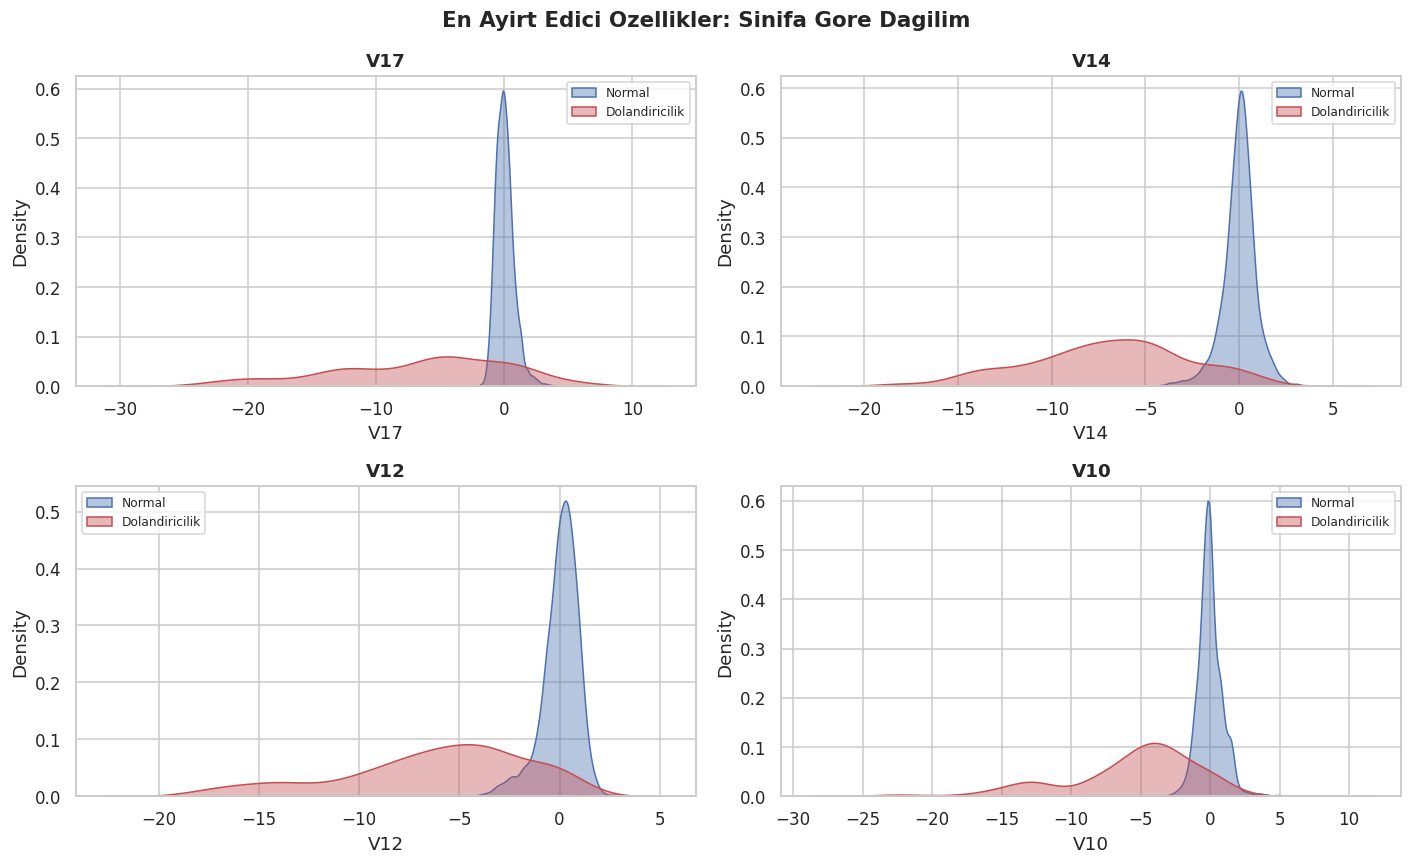

In [9]:
# En ayırt edici 4 özelliğin sınıfa göre dağılımı (normalleri örnekleyerek hızlandırıyoruz)
normal_sample = normal.sample(5000, random_state=RANDOM_STATE)
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, feat in zip(axes.ravel(), TOP_FEATS):
    sns.kdeplot(normal_sample[feat], ax=ax, label="Normal", fill=True,
                color="#4C72B0", alpha=0.4)
    sns.kdeplot(fraud[feat], ax=ax, label="Dolandiricilik", fill=True,
                color="#C44E52", alpha=0.4)
    ax.set_title(feat); ax.legend(fontsize=8)
fig.suptitle("En Ayirt Edici Ozellikler: Sinifa Gore Dagilim", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()

Bu PCA bileşenlerinde dolandırıcılık dağılımı normalden **belirgin biçimde kayar**. Isolation Forest, tam da bu çok-boyutlu sapmaları rastgele bölmelerle yakalar.

## 4. Veri Önişleme ve Eğitim/Test Ayrımı

**Metodoloji notu:** Isolation Forest gözetimsizdir; etiketi kullanmaz. Yine de dürüst değerlendirme için modeli **yalnızca eğitim** verisine fit edip **ayrık test** setinde skorluyoruz (sızıntıyı önlemek). Ayrımı `stratify` ile yapıyoruz ki test setinde de dolandırıcılık oranı korunsun.

**Ölçekleme:** Isolation Forest ağaç-temelli olduğundan **ölçekleme gerektirmez** (eşik bölmeleri ölçekten bağımsızdır). Ölçeklemeyi yalnızca Bölüm 12'deki mesafe-temelli LOF kıyası için yapacağız.


In [10]:
X = df.drop("Class", axis=1)
y = df["Class"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y)

print(f"Egitim: {X_train.shape[0]:,} islem | dolandiricilik: {int(y_train.sum())}")
print(f"Test  : {X_test.shape[0]:,} islem | dolandiricilik: {int(y_test.sum())}")
print(f"Test dolandiricilik orani: %{100*y_test.mean():.4f}")

Egitim: 199,364 islem | dolandiricilik: 344
Test  : 85,443 islem | dolandiricilik: 148
Test dolandiricilik orani: %0.1732


## 5. Isolation Forest Modelleme

`contamination`'ı veri-temelli (gözlenen dolandırıcılık oranı ≈ 0,001727) seçiyoruz. Pratikte bu oran bilinmeyebilir; o zaman eşik **inceleme kapasitesine** göre belirlenir (Bölüm 10–11).


In [11]:
CONTAMINATION = 0.001727  # gozlenen dolandiricilik orani

t0 = time.time()
iso = IsolationForest(
    n_estimators=200,
    max_samples="auto",      # 256
    contamination=CONTAMINATION,
    max_features=1.0,
    random_state=RANDOM_STATE,
    n_jobs=-1,
).fit(X_train)              # ETIKET KULLANILMADI
print(f"Egitim suresi: {time.time()-t0:.1f}s | n_estimators=200")

# Anomali skoru: yuksek = daha anormal
train_scores = -iso.score_samples(X_train)
test_scores = -iso.score_samples(X_test)
test_pred = (iso.predict(X_test) == -1).astype(int)
print("Skorlar hesaplandi (yuksek skor = daha supheli).")

Egitim suresi: 2.6s | n_estimators=200
Skorlar hesaplandi (yuksek skor = daha supheli).


## 6. Anomali Skorları ve Eşik

Modelin kalbi **anomali skorudur**. İyi bir model, dolandırıcılık skorlarını normalden ayırır. `contamination` eşiği (kırmızı çizgi), skoru karara (`1/−1`) çevirir.


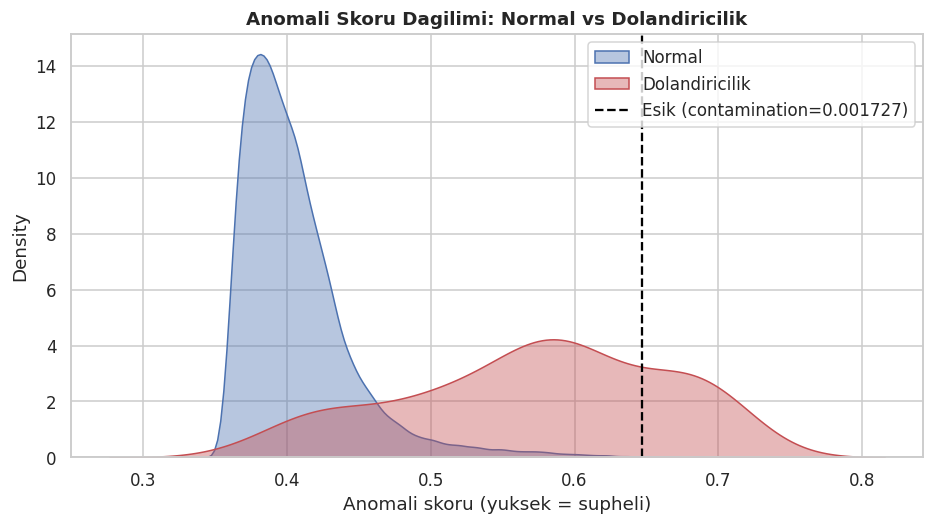

In [12]:
# contamination eşiğine karşılık gelen skor kesimi
thr_default = np.quantile(test_scores, 1 - CONTAMINATION)

fig, ax = plt.subplots(figsize=(10, 5))
sns.kdeplot(test_scores[y_test == 0], label="Normal", fill=True,
            color="#4C72B0", alpha=0.4, ax=ax)
sns.kdeplot(test_scores[y_test == 1], label="Dolandiricilik", fill=True,
            color="#C44E52", alpha=0.4, ax=ax)
ax.axvline(thr_default, color="black", ls="--",
           label=f"Esik (contamination={CONTAMINATION})")
ax.set_xlabel("Anomali skoru (yuksek = supheli)")
ax.set_title("Anomali Skoru Dagilimi: Normal vs Dolandiricilik")
ax.legend()
plt.show()

Dolandırıcılık dağılımı sağa (yüksek skor) belirgin biçimde kaymış — model gerçek sinyal yakalıyor. Ancak iki dağılımın **örtüşen** bir bölgesi var; bu örtüşme, mükemmel ayrımın mümkün olmadığını ve eşik seçiminin bir **takas (trade-off)** olduğunu gösterir.

## 7. Değerlendirme (Dengesizliğe Duyarlı)

### 7.1 Varsayılan Eşikle Sınıflandırma Raporu


In [13]:
print("Karmasiklik matrisi (test):")
print(confusion_matrix(y_test, test_pred))
print("\nSiniflandirma raporu:")
print(classification_report(y_test, test_pred, digits=3,
                            target_names=["Normal", "Dolandiricilik"]))

roc = roc_auc_score(y_test, test_scores)
pr = average_precision_score(y_test, test_scores)
print(f"ROC-AUC : {roc:.4f}")
print(f"PR-AUC  : {pr:.4f}   <-- dengesiz veride ASIL metrik")

Karmasiklik matrisi (test):
[[85188   107]
 [  113    35]]

Siniflandirma raporu:
                precision    recall  f1-score   support

        Normal      0.999     0.999     0.999     85295
Dolandiricilik      0.246     0.236     0.241       148

      accuracy                          0.997     85443
     macro avg      0.623     0.618     0.620     85443
  weighted avg      0.997     0.997     0.997     85443

ROC-AUC : 0.9460
PR-AUC  : 0.1374   <-- dengesiz veride ASIL metrik


> **Kritik nokta:** ROC-AUC ≈ 0,95 göz alıcıdır ama yanıltıcıdır. %0,17 yaygınlıkta ROC eğrisi, devasa normal kütlesi yüzünden iyimser çıkar. **PR-AUC (ortalama hassasiyet)** gerçek zorluğu yansıtır ve burada çok daha düşüktür. Dengesiz problemlerde **daima PR-AUC raporlayın.**

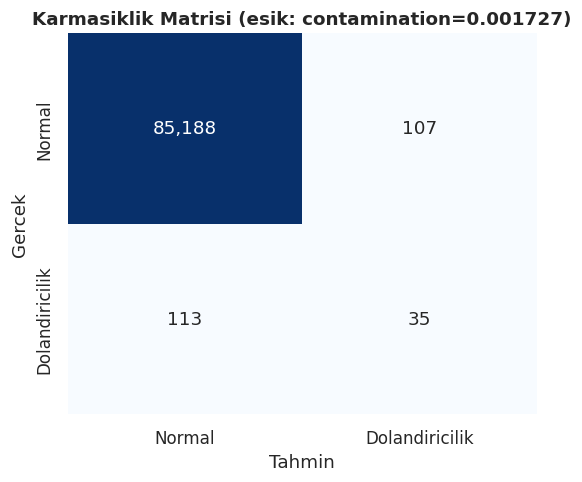

In [14]:
# Karmaşıklık matrisi ısı haritası
cm = confusion_matrix(y_test, test_pred)
fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", cbar=False, ax=ax,
            xticklabels=["Normal", "Dolandiricilik"],
            yticklabels=["Normal", "Dolandiricilik"])
ax.set_xlabel("Tahmin"); ax.set_ylabel("Gercek")
ax.set_title(f"Karmasiklik Matrisi (esik: contamination={CONTAMINATION})")
plt.show()

### 7.2 ROC ve Precision–Recall Eğrileri

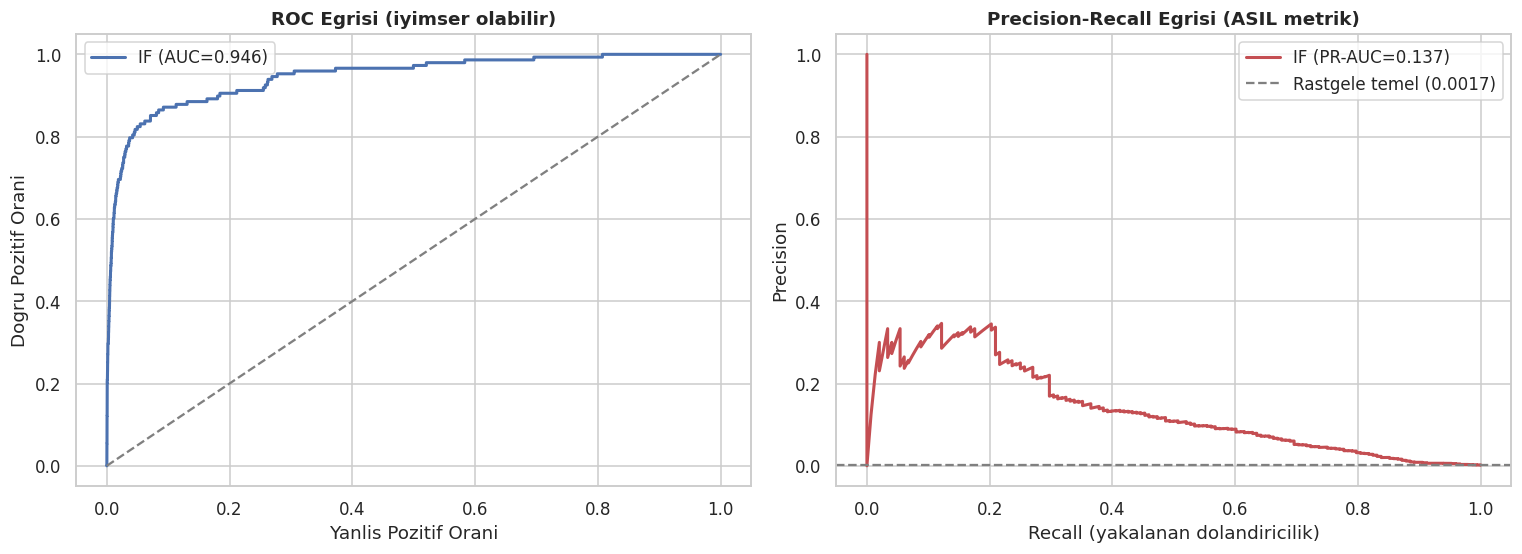

In [15]:
fpr, tpr, _ = roc_curve(y_test, test_scores)
prec, rec, _ = precision_recall_curve(y_test, test_scores)
baseline = y_test.mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))
axes[0].plot(fpr, tpr, color="#4C72B0", lw=2, label=f"IF (AUC={roc:.3f})")
axes[0].plot([0, 1], [0, 1], "--", color="gray")
axes[0].set_xlabel("Yanlis Pozitif Orani"); axes[0].set_ylabel("Dogru Pozitif Orani")
axes[0].set_title("ROC Egrisi (iyimser olabilir)"); axes[0].legend()

axes[1].plot(rec, prec, color="#C44E52", lw=2, label=f"IF (PR-AUC={pr:.3f})")
axes[1].axhline(baseline, ls="--", color="gray",
                label=f"Rastgele temel ({baseline:.4f})")
axes[1].set_xlabel("Recall (yakalanan dolandiricilik)")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Egrisi (ASIL metrik)"); axes[1].legend()
fig.tight_layout()
plt.show()

## 8. Operasyonel Görünüm: Top-K İnceleme (Lift)

Gerçek bankacılıkta anomali skoru ikili karara değil, bir **öncelik sırasına** dönüştürülür: "İnceleme ekibi günde en şüpheli %X işlemi inceleyebilir." Asıl soru: **%X'i incelersek dolandırıcılığın yüzde kaçını yakalarız?** (Top-K yakalama / lift eğrisi.)


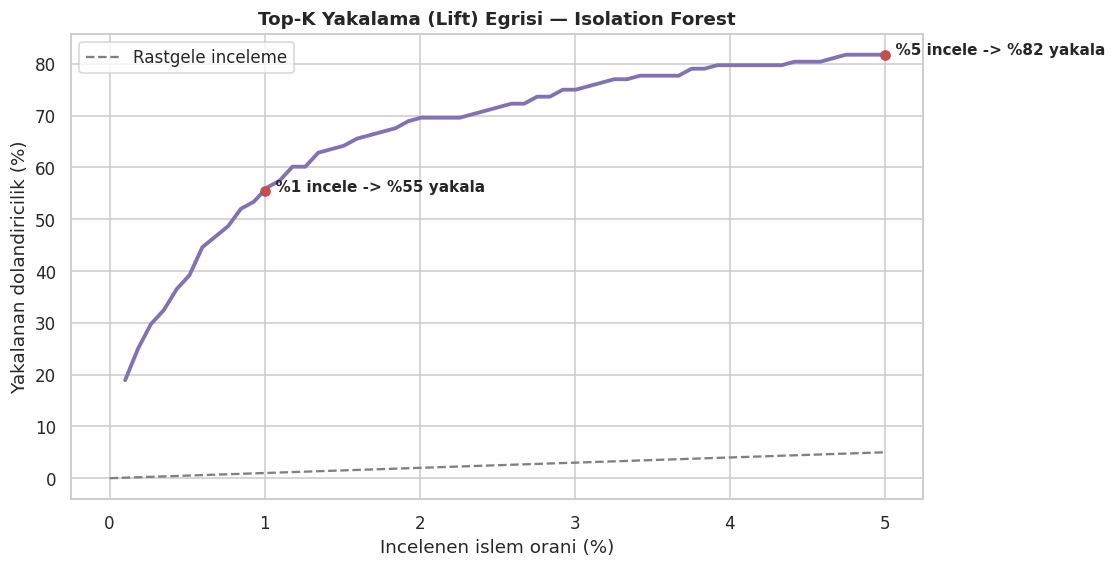

In [16]:
order = np.argsort(-test_scores)              # en supheliden en az supheliye
N, F = len(y_test), int(y_test.sum())
fractions = np.linspace(0.001, 0.05, 60)
recalls = [y_test[order[:max(1, int(N * p))]].sum() / F for p in fractions]

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(fractions * 100, np.array(recalls) * 100, color="#8172B3", lw=2.5)
for p in [0.01, 0.05]:
    r = y_test[order[:int(N * p)]].sum() / F
    ax.scatter([p * 100], [r * 100], color="#C44E52", zorder=5)
    ax.annotate(f"  %{p*100:.0f} incele -> %{r*100:.0f} yakala",
                (p * 100, r * 100), fontsize=10, fontweight="bold")
ax.plot([0, 5], [0, 5], "--", color="gray", label="Rastgele inceleme")
ax.set_xlabel("Incelenen islem orani (%)")
ax.set_ylabel("Yakalanan dolandiricilik (%)")
ax.set_title("Top-K Yakalama (Lift) Egrisi — Isolation Forest")
ax.legend()
plt.show()

In [17]:
print("Inceleme kapasitesi senaryolari (test seti):")
for p in [0.005, 0.01, 0.02, 0.05]:
    k = int(N * p)
    cap = y_test[order[:k]].sum()
    print(f"  En supheli %{p*100:>4.1f} ({k:>5,} islem) -> "
          f"{int(cap):>3}/{F} dolandiricilik yakalandi (recall %{100*cap/F:.1f})")
print("\nRastgele incelemede %1 -> ~%1 yakalanirdi. IF ile %1 -> ~%55: ~55x lift.")

Inceleme kapasitesi senaryolari (test seti):
  En supheli % 0.5 (  427 islem) ->  57/148 dolandiricilik yakalandi (recall %38.5)
  En supheli % 1.0 (  854 islem) ->  82/148 dolandiricilik yakalandi (recall %55.4)
  En supheli % 2.0 (1,708 islem) -> 103/148 dolandiricilik yakalandi (recall %69.6)
  En supheli % 5.0 (4,272 islem) -> 121/148 dolandiricilik yakalandi (recall %81.8)

Rastgele incelemede %1 -> ~%1 yakalanirdi. IF ile %1 -> ~%55: ~55x lift.


## 9. Eşik / İnceleme Oranı Seçimi

Eşik tek doğru değildir; **precision–recall takasıdır.** Alarm oranını (incelenen %) artırdıkça recall yükselir, precision düşer. Operasyonel nokta, **inceleme kapasitesi** ve **maliyet asimetrisi** ile belirlenir.


En iyi F1: %0.18 alarm oraninda -> precision=0.237, recall=0.250, F1=0.243


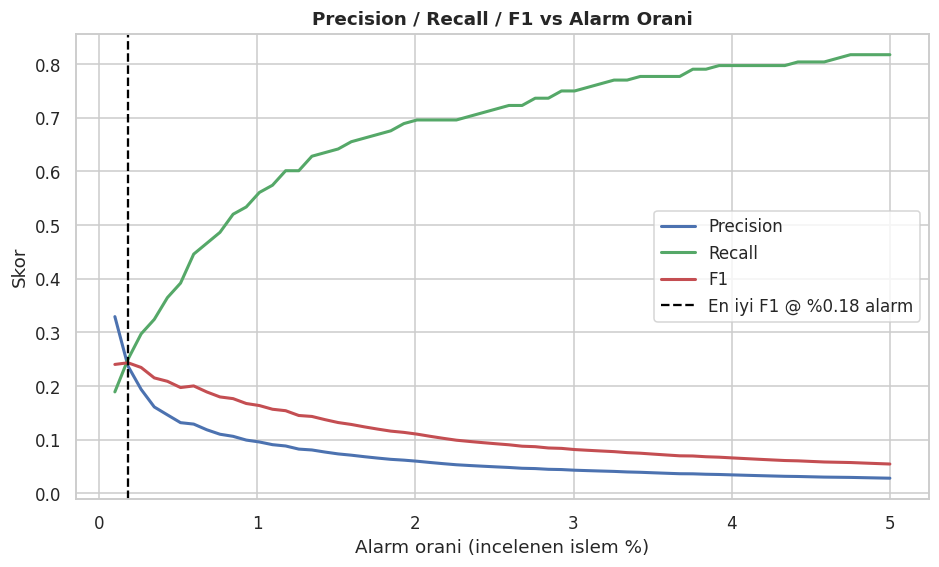

In [18]:
alert_rates = np.linspace(0.001, 0.05, 60)
P, R, Fb = [], [], []
for a in alert_rates:
    k = max(1, int(N * a))
    flagged = order[:k]
    tp = y_test[flagged].sum()
    p_ = tp / k
    r_ = tp / F
    P.append(p_); R.append(r_)
    Fb.append(2 * p_ * r_ / (p_ + r_ + 1e-12))

best = int(np.argmax(Fb))
best_a = alert_rates[best]

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(alert_rates * 100, P, label="Precision", color="#4C72B0", lw=2)
ax.plot(alert_rates * 100, R, label="Recall", color="#55A868", lw=2)
ax.plot(alert_rates * 100, Fb, label="F1", color="#C44E52", lw=2)
ax.axvline(best_a * 100, ls="--", color="black",
           label=f"En iyi F1 @ %{best_a*100:.2f} alarm")
ax.set_xlabel("Alarm orani (incelenen islem %)")
ax.set_ylabel("Skor")
ax.set_title("Precision / Recall / F1 vs Alarm Orani")
ax.legend()
plt.show()
print(f"En iyi F1: %{best_a*100:.2f} alarm oraninda -> "
      f"precision={P[best]:.3f}, recall={R[best]:.3f}, F1={Fb[best]:.3f}")

Tek bir "doğru" eşik yoktur: dolandırıcılığın çoğunu yakalamak isteyen banka recall'ı, az personeli olan banka precision'ı önceler. Isolation Forest skoru, bu kararı **iş tarafına bırakacak şekilde** sürekli bir sıralama sağlar.

## 10. Yöntem Karşılaştırması: IF vs LOF vs Hibrit

Önceki çalışmalardaki çoklu-yöntem kıyasının anomali-tespiti karşılığı. Üç yaklaşımı aynı eğitim/test ayrımında kıyaslıyoruz:

1. **Isolation Forest** (gözetimsiz, izolasyon-temelli)
2. **Local Outlier Factor** (gözetimsiz, **mesafe/yoğunluk-temelli**) — yüksek boyutta davranışı kritik
3. **Hibrit** (IF skoru → **gözetimli** gradient boosting) — etiket mevcutken tavan performans


In [19]:
# LOF mesafe-temelli -> olcekleme sart. Test setinde fit_predict (~30-40s).
scaler = RobustScaler().fit(X_train)
X_test_scaled = scaler.transform(X_test)

t0 = time.time()
lof = LocalOutlierFactor(n_neighbors=20, contamination=CONTAMINATION, n_jobs=-1)
lof.fit_predict(X_test_scaled)
lof_scores = -lof.negative_outlier_factor_
print(f"LOF skorlama suresi: {time.time()-t0:.1f}s ({len(X_test):,} test noktasi)")
print(f"LOF  -> ROC-AUC {roc_auc_score(y_test, lof_scores):.4f} | "
      f"PR-AUC {average_precision_score(y_test, lof_scores):.4f}")

LOF skorlama suresi: 39.8s (85,443 test noktasi)
LOF  -> ROC-AUC 0.6393 | PR-AUC 0.0051


LOF'un PR-AUC'u neredeyse **rastgele temel** seviyesinde. Sebep: 30 PCA boyutunda "yerel yoğunluk" anlamını yitirir (boyut laneti). Bu, **neden yüksek boyutlu anomali tespitinde Isolation Forest tercih edildiğinin** somut kanıtıdır.

In [20]:
# Hibrit: IF skorunu özellik olarak ekle -> denetimli gradient boosting (etiket KULLANIR)
Xtr_h = X_train.copy(); Xte_h = X_test.copy()
Xtr_h["iso_score"] = train_scores
Xte_h["iso_score"] = test_scores

t0 = time.time()
clf = HistGradientBoostingClassifier(
    random_state=RANDOM_STATE, class_weight="balanced",
    learning_rate=0.1, max_iter=200).fit(Xtr_h, y_train)
hybrid_proba = clf.predict_proba(Xte_h)[:, 1]
print(f"Hibrit egitim: {time.time()-t0:.1f}s")
print(f"Hibrit -> ROC-AUC {roc_auc_score(y_test, hybrid_proba):.4f} | "
      f"PR-AUC {average_precision_score(y_test, hybrid_proba):.4f}")

Hibrit egitim: 3.3s
Hibrit -> ROC-AUC 0.9536 | PR-AUC 0.7282


In [21]:
def scores_row(name, s, supervised=False):
    return {"Yontem": name,
            "Denetim": "Gozetimli" if supervised else "Gozetimsiz",
            "ROC-AUC": round(roc_auc_score(y_test, s), 4),
            "PR-AUC": round(average_precision_score(y_test, s), 4)}

comparison = pd.DataFrame([
    scores_row("Isolation Forest", test_scores),
    scores_row("Local Outlier Factor", lof_scores),
    scores_row("Hibrit (IF -> GradBoost)", hybrid_proba, supervised=True),
]).set_index("Yontem")
comparison

,Denetim,ROC-AUC,PR-AUC
Yontem,,,
Isolation Forest,Gozetimsiz,0.9460,0.1374
Local Outlier Factor,Gozetimsiz,0.6393,0.0051
Hibrit (IF -> GradBoost),Gozetimli,0.9536,0.7282


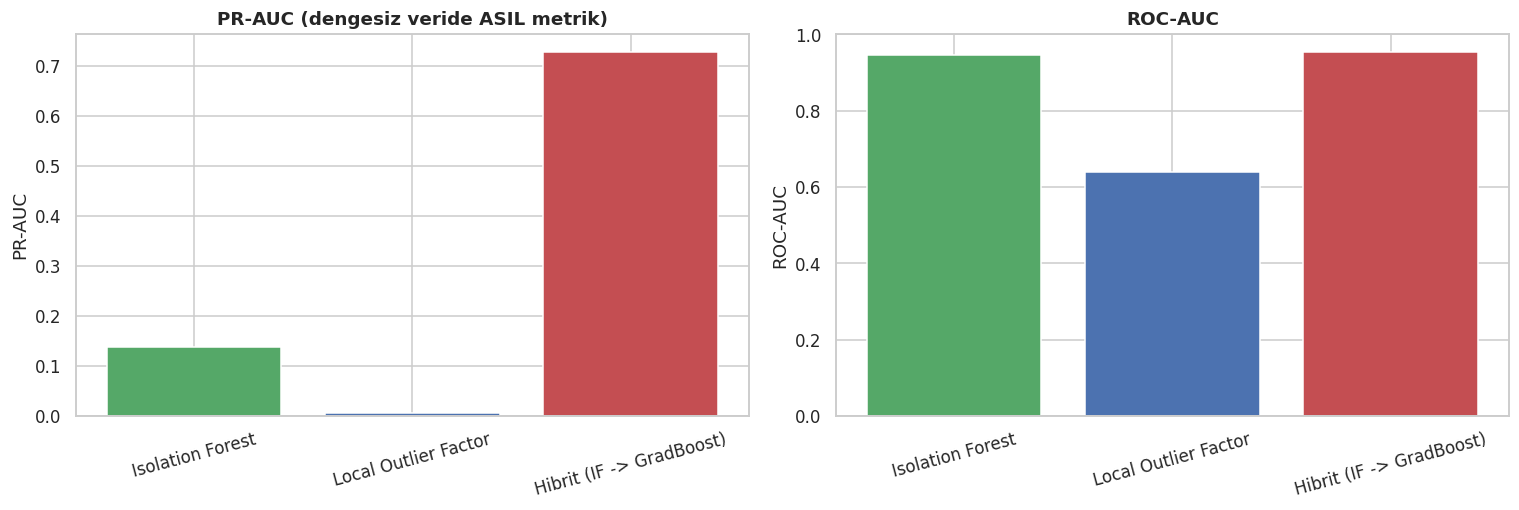

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
methods = comparison.index.tolist()
cols = ["#55A868", "#4C72B0", "#C44E52"]
axes[0].bar(methods, comparison["PR-AUC"], color=cols)
axes[0].set_title("PR-AUC (dengesiz veride ASIL metrik)")
axes[0].set_ylabel("PR-AUC"); axes[0].tick_params(axis="x", rotation=15)
axes[1].bar(methods, comparison["ROC-AUC"], color=cols)
axes[1].set_title("ROC-AUC")
axes[1].set_ylabel("ROC-AUC"); axes[1].tick_params(axis="x", rotation=15)
fig.tight_layout()
plt.show()

**Okuma:**
- **IF >> LOF:** Yüksek boyutta izolasyon-temelli yaklaşım, mesafe-temelliyi ezici biçimde geçer.
- **Hibrit >> IF:** Etiket *mevcutsa* denetimli model PR-AUC'u kat kat artırır. Ama bu etiket gerektirir; IF'in değeri tam da etiketin **az/olmadığı**, **yeni** dolandırıcılığın görülmesi gereken durumlardadır.
- **En iyi pratik mimari:** IF'i (a) soğuk başlangıçta tek başına, (b) etiket biriktikçe **özellik üreteci** olarak kullan → "gözetimsiz → gözetimli → insan" hattı.

İşlemleri inceleme için dışa aktaralım (operasyonel çıktı):


In [23]:
results = X_test.copy()
results["gercek_class"] = y_test
results["anomali_skoru"] = test_scores
results["if_tahmin"] = test_pred
results = results.sort_values("anomali_skoru", ascending=False)
top_susp = results.head(int(N * 0.01))   # en supheli %1
out_path = "/mnt/user-data/outputs/top_supheli_islemler.csv"
top_susp[["Time", "Amount", "anomali_skoru", "if_tahmin", "gercek_class"]].to_csv(out_path)
print(f"En supheli %1 ({len(top_susp):,} islem) kaydedildi -> {out_path}")
print(f"Bu listede {int(top_susp['gercek_class'].sum())} gercek dolandiricilik var "
      f"(tum test dolandiriciliklarinin %{100*top_susp['gercek_class'].sum()/F:.0f}'i).")
top_susp[["Time", "Amount", "anomali_skoru", "if_tahmin", "gercek_class"]].head(10)

En supheli %1 (854 islem) kaydedildi -> /mnt/user-data/outputs/top_supheli_islemler.csv
Bu listede 82 gercek dolandiricilik var (tum test dolandiriciliklarinin %55'i).


,Time,Amount,anomali_skoru,if_tahmin,gercek_class
173353,121450.0,4861.64,0.753546,1,0
220090,142019.0,5964.95,0.748775,1,0
176335,122723.0,1676.60,0.748719,1,0
46841,42951.0,12910.93,0.738993,1,0
219257,141655.0,3502.11,0.726343,1,0
262839,160669.0,1441.06,0.725392,1,0
201775,134033.0,1402.38,0.723000,1,0
43428,41505.0,364.19,0.716826,1,1
153823,100223.0,2.28,0.716327,1,1
154234,100924.0,1.00,0.715933,1,1


<a id="13"></a>
## 13. Sonuç, Sınırlılıklar ve Üretim Notları

### Sonuç
- Isolation Forest, 284 bin işlemi saniyeler içinde işleyip dolandırıcılığı **etiketsiz** güçlü biçimde sıralar (ROC-AUC ≈ 0,95).
- **Metrik disiplini:** %0,17 yaygınlıkta accuracy ve ROC-AUC yanıltıcıdır; **PR-AUC ve Top-K recall** raporlanmalıdır.
- **Operasyonel güç:** En şüpheli %1'i incelemek dolandırıcılığın ~%55'ini, %5'i ~%82'sini yakalar — sınırlı kapasitede yüksek getiri (lift).
- **Yöntem seçimi:** Yüksek boyutta IF, mesafe-temelli LOF'u ezer; etiket mevcutsa IF skoru bir denetimli modeli besleyerek PR-AUC'u kat kat artırır.

### Sınırlılıklar
- IF skoru bir **olasılık değildir**; eşik iş kararıdır (kalibrasyon için `predict_proba`'lı denetimli katman gerekir).
- `contamination` gerçek oranı bilinmiyorsa bir varsayımdır; eşiği **kapasiteye** göre seçmek daha sağlıklıdır.
- Aşırı örtüşen bölgelerde IF tek başına yetersiz kalır → hibrit mimari önerilir.
- V1–V28 PCA olduğundan **yorumlanabilirlik sınırlıdır**; gerçek özelliklerle SHAP vb. açıklanabilirlik eklenmelidir.

### Üretim Notları
- **Veri kayması (drift):** Dolandırıcılık kalıpları değişir; modeli periyodik yeniden eğitin ve skor dağılımını izleyin.
- **Eşik yönetişimi:** Eşiği inceleme kapasitesine bağlayın; precision/recall'ı canlı izleyin.
- **Gerçek-zamanlı skorlama:** IF `score_samples` hızlıdır; düşük gecikmeli skorlama için uygundur. Yeni işlemler doğrudan skorlanır.
- **Hibrit hat:** IF skorunu özellik deposuna (feature store) yazıp denetimli modele besleyin; insan incelemesinden gelen etiketleri geri besleyin (aktif öğrenme).
- **İzlenebilirlik:** `n_estimators`, `max_samples`, `contamination`, tohum ve eğitim verisi sürümü kaydedilmeli (MLflow vb.).